In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [5]:
folder = f'비공개'
IMG_DIR = os.path.join(folder, 'boneage-training-dataset')
CSV_PATH = os.path.join(folder, 'boneage-training-dataset.csv') #boneage = months
print(f'image path:{IMG_DIR}')
df = pd.read_csv(CSV_PATH)
print(df.head())

image path:C:/medicalAI/Pycham/sample/bone/bone_sample\boneage-training-dataset
     id  boneage   male
0  1377      180  False
1  1378       12  False
2  1379       94  False
3  1380      120   True
4  1381       82  False


In [6]:
#boneage sample(months)
group = { "baby_24m" : df[df["boneage"] <=36].iloc[0],
        "child_84" : df[(df["boneage"] >=72) & (df["boneage"] <= 96)].iloc[0],
        "teen_156m" : df[(df["boneage"] >=144) & (df["boneage"] <= 196)].iloc[0],
        "adult_216m" : df[df["boneage"] >=210].iloc[0]
}
print(group)

{'baby_24m': id          1378
boneage       12
male       False
Name: 1, dtype: object, 'child_84': id          1379
boneage       94
male       False
Name: 2, dtype: object, 'teen_156m': id          1377
boneage      180
male       False
Name: 0, dtype: object, 'adult_216m': id         1466
boneage     216
male       True
Name: 78, dtype: object}


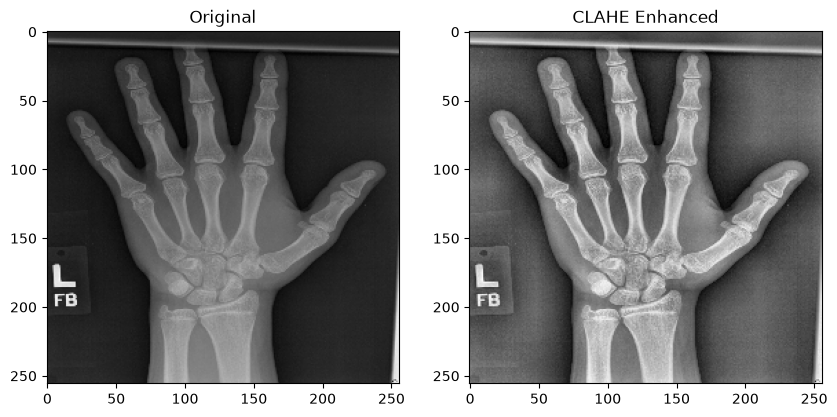

In [18]:
#CLAHE : Contrast Limited Adaptive Histogram Equalization
#대비효과이용
import cv2
import os
import matplotlib.pyplot as plt

# 1. 미정의된 TARGET_SIZE 변수 선언 (가로, 세로 튜플 형태)
TARGET_SIZE = (256, 256)

# 2. 전처리 함수 (오타 수정)
def preprocess(img):
    resized = cv2.resize(img, TARGET_SIZE)
    # clache -> clahe, titleGridSize -> tileGridSize 로 수정
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(resized)
    return enhanced

# 3. 이미지 로드 및 전처리 실행
sample_id = group["adult_216m"]["id"]
sample_path = os.path.join(IMG_DIR, f"{sample_id}.png")
img_orig = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

img_enhanced = preprocess(img_orig)

# 4. 시각화 (오른쪽 출력 대상을 img_enhanced로 변경)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(cv2.resize(img_orig, TARGET_SIZE), cmap='gray')

plt.subplot(1, 2, 2)
plt.title("CLAHE Enhanced")
plt.imshow(img_enhanced, cmap='gray')  # img_orig 대신 처리된 img_enhanced 출력

plt.show()

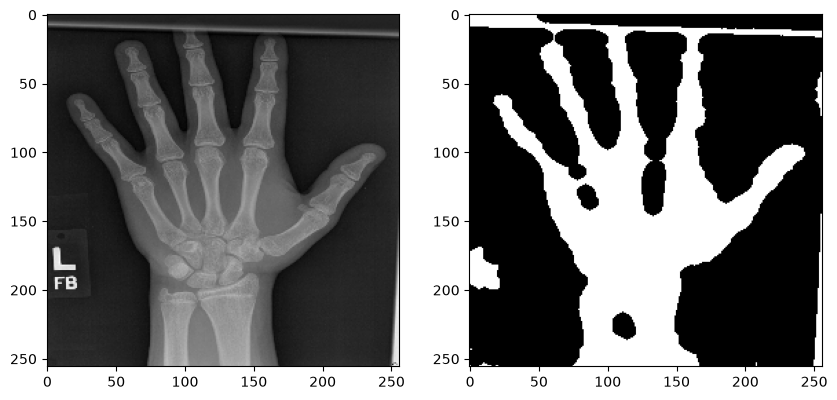

In [19]:
# bone part making
#create bone mask for extract edge, delete noise
def segment_bone_region(img):
    _, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    return mask
bone_mask = segment_bone_region(img_enhanced)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv2.resize(img_orig, TARGET_SIZE), cmap='gray')
plt.subplot(1, 2, 2);plt.imshow(cv2.resize(bone_mask, TARGET_SIZE), cmap='gray')
plt.show()

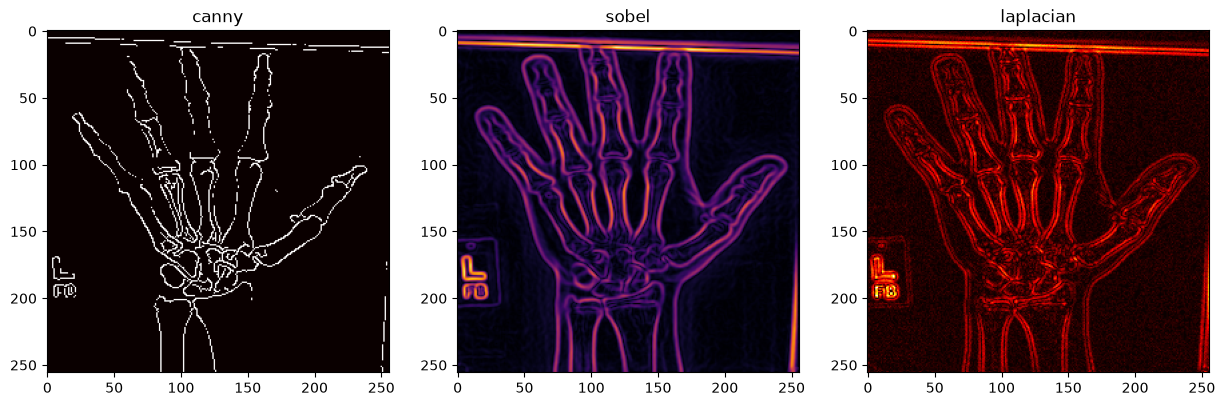

In [22]:
#extrac edge, compare algorithms
#canny: 노이즈에 강하며 얇고 선명한 엣지 추출
#sobel: 이미지의 기울기를 이용하여 엣지 강도를 나타냄
#Laplacian: 2차 미분을 활용하여 급격한 변화 일어나는 지점 찾음
def detect_edges(img):
    #canny
    blurred = cv2.GaussianBlur(img, (5,5), 0)
    median = np.median(blurred)
    low, high = int(max(0, 0.04 * median)), int(min(255, 1.6*median))
    canny = cv2.Canny(blurred, low, high)
    #sobel
    sx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.uint8(cv2.normalize(np.sqrt(sx**2 + sy**2), None, 0, 255, cv2.NORM_MINMAX))
    #laplacian
    laplacian = cv2.convertScaleAbs(cv2.Laplacian(blurred, cv2.CV_64F))
    return canny, sobel, laplacian
canny, sobel, lap = detect_edges(img_enhanced)

canny_bone = cv2.bitwise_and(canny, bone_mask)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(canny_bone, cmap='hot'); plt.title('canny')
plt.subplot(1, 3, 2); plt.imshow(sobel, cmap='inferno'); plt.title('sobel')
plt.subplot(1, 3, 3); plt.imshow(lap, cmap='hot'); plt.title('laplacian')
plt.show()

In [28]:
#density edge
def analyze_bone_edge(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    proc = preprocess(img)
    mask = segment_bone_region(proc)
    canny, _, _ = detect_edges(proc)
    canny_bone = cv2.bitwise_and(canny, mask)
    #dense
    edge_pixels = np.sum(canny_bone>0)
    bone_pixels = np.sum(mask >0)
    density = (edge_pixels / bone_pixels) * 100 if bone_pixels >0 else 0
    return density

In [30]:
for nm, row, in group.items():
    img_id = row["id"]
    img_path = os.path.join(IMG_DIR, f'{img_id}.png')
    density = analyze_bone_edge(img_path)
    print(f'{nm}age: {round(density, 2)}%')
    

baby_24mage: 0.49%
child_84age: 4.31%
teen_156mage: 21.59%
adult_216mage: 13.81%
